# 01 · LMM predicted trajectories (fixes convergence) + Waterfall of Δpain

## Goals
1. Refit the trajectory-phase LMM for `NP1PAIN` using **months** instead of days to resolve the near-unidentifiable warning seen in the sleep notebook (`max|grad| = 12.35`).
2. Produce **Figure 6-equivalent** predicted trajectories by `traj` (Pre-DBS / Post-DBS / Never-DBS), with 95% CI.
3. Produce a **waterfall plot** of per-patient Δpain (post vs pre) among future-DBS patients — single image to expose heterogeneity behind the null mean.
4. Export a responder label (`Δpain ≤ −1`) for use in the prediction-model notebook.


In [1]:
source("helpers/pain_helpers.R")
suppressPackageStartupMessages({
  library(lme4); library(lmerTest); library(emmeans); library(patchwork)
})
df_long <- readRDS(file.path(OUT_OBJ, "pain_long.rds"))
cat("Rows:", nrow(df_long), "  Patients:", dplyr::n_distinct(df_long$PATNO), "\n")

Rows: 6320   Patients: 170 


## 1. Exclude very long pre-DBS spans (same rule as sleep Rmd)

In [2]:
dbs_ids <- df_long %>% dplyr::filter(traj == "Post-DBS") %>% dplyr::pull(PATNO) %>% unique()

exclude_ids <- df_long %>%
  dplyr::filter(traj == "Pre-DBS", PATNO %in% dbs_ids) %>%
  dplyr::group_by(PATNO) %>%
  dplyr::summarise(max_pre_months = max(time_pos_months, na.rm = TRUE), .groups = "drop") %>%
  dplyr::filter(max_pre_months > 60) %>%
  dplyr::pull(PATNO)

lmm_data <- df_long %>%
  dplyr::filter(!PATNO %in% exclude_ids) %>%
  dplyr::mutate(time = time_pos_months)

cat("Patients excluded (pre-DBS span > 60 months):", length(exclude_ids), "\n")
cat("Rows retained:", nrow(lmm_data), "  Patients:", dplyr::n_distinct(lmm_data$PATNO), "\n")

Patients excluded (pre-DBS span > 60 months): 3 


Rows retained: 6206   Patients: 167 


## 2. Fit weighted LMM: `NP1PAIN ~ time * traj + (1 + time | PATNO)`
Using months keeps the eigenvalue balanced; `time` in days produced a ~180× scale mismatch vs the intercept, which was the cause of the convergence warning in the sleep notebook.

In [3]:
m_pain <- lme4::lmer(
  NP1PAIN ~ time * traj + (1 + time | PATNO),
  data = lmm_data,
  weights = weight_sw_trim90,
  REML = FALSE
)

# Diagnostics: convergence and scale
cat("Converged:", isTRUE(all(abs(m_pain@optinfo$derivs$gradient) < 0.002)), "\n")
print(m_pain@optinfo$conv$lme4)
summary(m_pain)$coefficients

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.0120475 (tol = 0.002, component 1)”


Converged: FALSE 


$code
[1] -1

$messages
[1] "Model failed to converge with max|grad| = 0.0120475 (tol = 0.002, component 1)"



,Estimate,Std. Error,t value
(Intercept),1.040316904,0.111729384,9.3110413
time,-0.005255217,0.005194677,-1.0116543
trajPost-DBS,0.114123922,0.045681810,2.4982356
trajNever-DBS,-0.080173670,0.141288933,-0.5674448
time:trajPost-DBS,0.010666763,0.003268065,3.2639388
time:trajNever-DBS,0.007931735,0.006596773,1.2023659


In [4]:
# Phase-specific slope per month, with tukey-adjusted pairwise contrasts
sl <- emmeans::emtrends(m_pain, specs = "traj", var = "time")
print(sl)
contrasts_tbl <- as.data.frame(pairs(sl, adjust = "tukey"))
print(contrasts_tbl)
save_table(contrasts_tbl, "lmm_slope_contrasts")

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 6206' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 6206)' or larger];
but be warned that this may result in large computation time and memory use.



Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 6206' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 6206)' or larger];
but be warned that this may result in large computation time and memory use.



 traj      time.trend      SE  df asymp.LCL asymp.UCL
 Pre-DBS     -0.00526 0.00519 Inf  -0.01544   0.00493
 Post-DBS     0.00541 0.00454 Inf  -0.00348   0.01431
 Never-DBS    0.00268 0.00407 Inf  -0.00529   0.01065

Degrees-of-freedom method: asymptotic 
Confidence level used: 0.95 


 contrast                     estimate          SE  df z.ratio p.value
 (Pre-DBS) - (Post-DBS)   -0.010666763 0.003268065 Inf  -3.264  0.0032
 (Pre-DBS) - (Never-DBS)  -0.007931735 0.006596773 Inf  -1.202  0.4517
 (Post-DBS) - (Never-DBS)  0.002735029 0.006092812 Inf   0.449  0.8949

Degrees-of-freedom method: asymptotic 
P value adjustment: tukey method for comparing a family of 3 estimates 


## 3. Predicted trajectories (0–60 months) with 95% CI

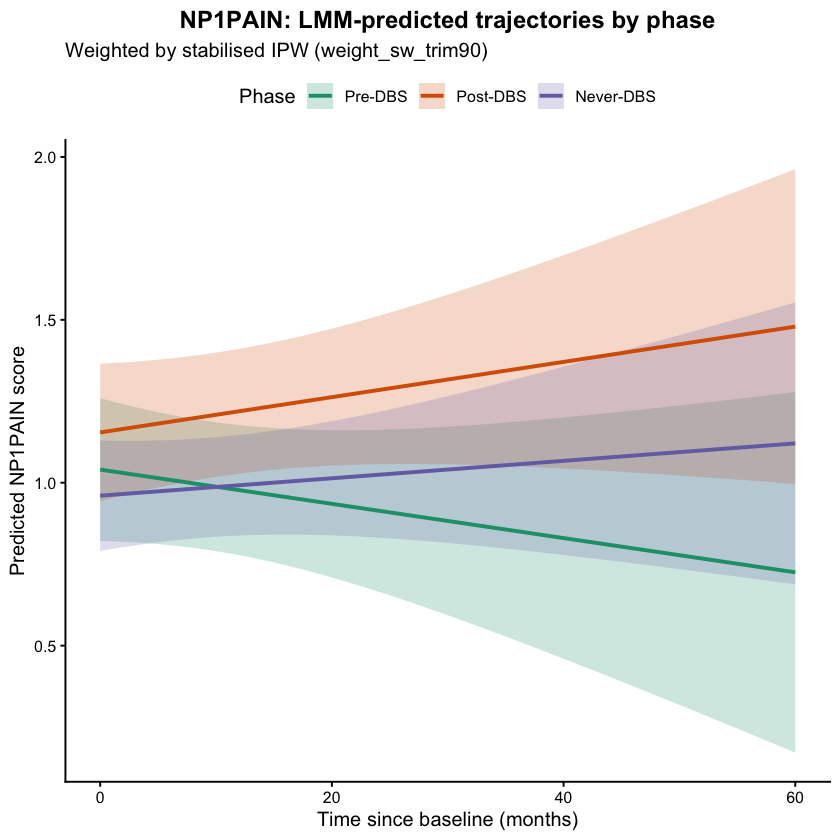

In [5]:
grid <- expand.grid(
  time = seq(0, 60, length.out = 200),
  traj = factor(c("Pre-DBS","Post-DBS","Never-DBS"),
                levels = c("Pre-DBS","Post-DBS","Never-DBS"))
)
pr <- predict(m_pain, newdata = grid, re.form = NA, se.fit = TRUE)
pred <- dplyr::bind_cols(grid, tibble::tibble(
  fit = pr$fit, lci = pr$fit - 1.96 * pr$se.fit, uci = pr$fit + 1.96 * pr$se.fit
))

p_pred <- ggplot(pred, aes(x = time, y = fit, colour = traj, fill = traj)) +
  geom_ribbon(aes(ymin = lci, ymax = uci), alpha = 0.22, colour = NA) +
  geom_line(linewidth = 1.1) +
  scale_colour_manual(values = TRAJ_COLORS, name = "Phase") +
  scale_fill_manual(values = TRAJ_COLORS, name = "Phase") +
  labs(title = "NP1PAIN: LMM-predicted trajectories by phase",
       subtitle = "Weighted by stabilised IPW (weight_sw_trim90)",
       x = "Time since baseline (months)", y = "Predicted NP1PAIN score") +
  theme_classic(base_size = 12) +
  theme(plot.title = element_text(face = "bold", hjust = 0.5),
        legend.position = "top")
p_pred
save_fig(p_pred, "Fig06_LMM_predicted_traj", width = 7.2, height = 4.6)

## 4. Waterfall of Δpain for future-DBS patients
Pre window = [−12, 0] months, Post window = [+6, +18] months (per-patient means, averaged over available visits in each window). Responder = Δ ≤ −1 point.

In [6]:
delta <- split_pre_post(df_long, var = "NP1PAIN",
                        windows = list(pre = c(-12, 0), post = c(6, 18)))

cat("Patients with both pre and post NP1PAIN observations:\n")
print(delta %>% dplyr::count(will_receive_dbs, name = "n"))

delta <- delta %>%
  dplyr::mutate(
    group = dplyr::if_else(will_receive_dbs, "DBS Group", "Never-DBS"),
    responder = dplyr::case_when(
      delta <= -1 ~ "Responder (Δ ≤ -1)",
      delta >= 1  ~ "Worsener (Δ ≥ +1)",
      TRUE        ~ "Stable (|Δ| < 1)"
    )
  )

dplyr::count(delta, group, responder) %>%
  tidyr::pivot_wider(names_from = responder, values_from = n, values_fill = 0)

Patients with both pre and post NP1PAIN observations:


# A tibble: 2 × 2
  will_receive_dbs     n
  <lgl>            <int>
1 FALSE               34
2 TRUE                40


group,Responder (Δ ≤ -1),Stable (|Δ| < 1),Worsener (Δ ≥ +1)
<chr>,<int>,<int>,<int>
DBS Group,5,30,5
Never-DBS,3,19,12


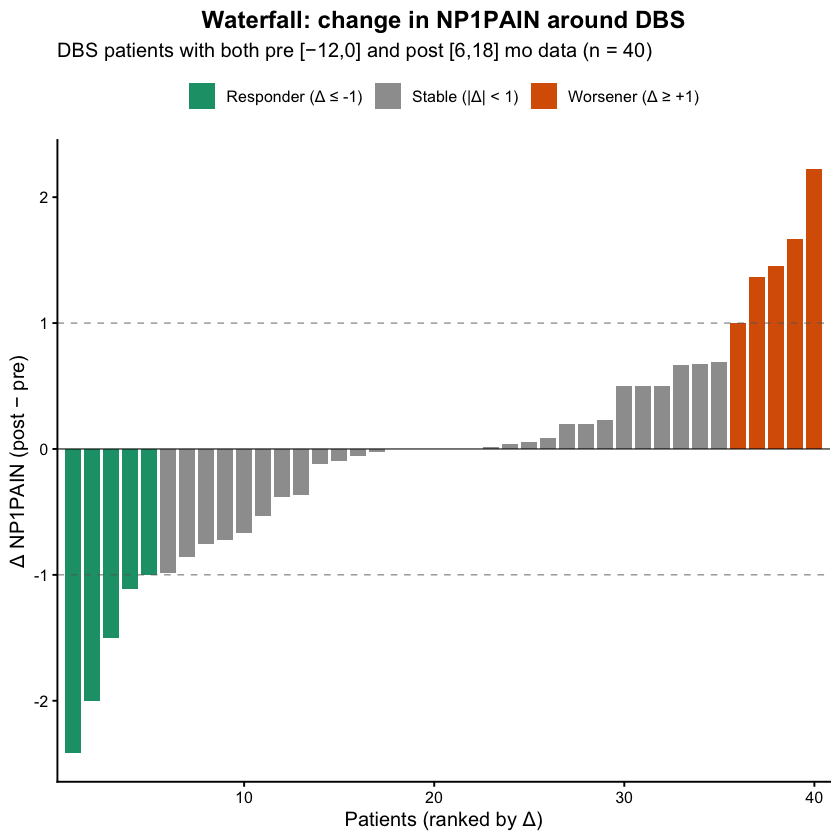

In [7]:
wf <- delta %>%
  dplyr::filter(will_receive_dbs) %>%
  dplyr::arrange(delta) %>%
  dplyr::mutate(rank = dplyr::row_number(),
                resp_col = factor(responder,
                                  levels = c("Responder (Δ ≤ -1)","Stable (|Δ| < 1)","Worsener (Δ ≥ +1)")))

resp_cols <- c("Responder (Δ ≤ -1)" = "#1b9e77",
               "Stable (|Δ| < 1)" = "#9E9E9E",
               "Worsener (Δ ≥ +1)" = "#d95f02")

p_wf <- ggplot(wf, aes(x = rank, y = delta, fill = resp_col)) +
  geom_col(width = 0.85) +
  geom_hline(yintercept = 0, linewidth = 0.3) +
  geom_hline(yintercept = c(-1, 1), linetype = "dashed", linewidth = 0.25, colour = "grey40") +
  scale_fill_manual(values = resp_cols, name = NULL) +
  scale_y_continuous("Δ NP1PAIN (post − pre)",
                     breaks = scales::pretty_breaks()) +
  scale_x_continuous("Patients (ranked by Δ)", expand = expansion(mult = c(0.01, 0.01))) +
  labs(title = "Waterfall: change in NP1PAIN around DBS",
       subtitle = sprintf("DBS patients with both pre [−12,0] and post [6,18] mo data (n = %d)", nrow(wf))) +
  theme_classic(base_size = 12) +
  theme(plot.title = element_text(face = "bold", hjust = 0.5),
        legend.position = "top")
p_wf
save_fig(p_wf, "Fig07_waterfall_dbs", width = 8, height = 4.6)

## 5. Comparison to Never-DBS controls (Δ distribution)

In [8]:
delta_summary <- delta %>% dplyr::group_by(group) %>%
  dplyr::summarise(n = dplyr::n(),
                   mean_delta = mean(delta),
                   sd_delta = stats::sd(delta),
                   median_delta = stats::median(delta),
                   pct_responder = mean(delta <= -1),
                   pct_worsener = mean(delta >= 1),
                   .groups = "drop")
print(delta_summary)
save_table(delta_summary, "delta_summary")

tt <- stats::t.test(delta ~ group, data = delta)
cat("\nWelch t-test on Δ (DBS vs Never-DBS): t =", signif(tt$statistic, 3),
    " p =", signif(tt$p.value, 3),
    " 95% CI of diff =", paste(signif(tt$conf.int, 3), collapse = ", "), "\n")

prop_tbl <- table(delta$group, ifelse(delta$delta <= -1, "Responder", "Non-responder"))
print(prop_tbl)
print(suppressWarnings(stats::chisq.test(prop_tbl)))

# A tibble: 2 × 7
  group         n mean_delta sd_delta median_delta pct_responder pct_worsener
  <chr>     <int>      <dbl>    <dbl>        <dbl>         <dbl>        <dbl>
1 DBS Group    40    -0.0380    0.920       0             0.125         0.125
2 Never-DBS    34     0.548     1.11        0.0161        0.0882        0.353



Welch t-test on Δ (DBS vs Never-DBS): t = -2.45  p = 0.017  95% CI of diff = -1.06, -0.109 


           
            Non-responder Responder
  DBS Group            35         5
  Never-DBS            31         3



	Pearson's Chi-squared test with Yates' continuity correction

data:  prop_tbl
X-squared = 0.017416, df = 1, p-value = 0.895



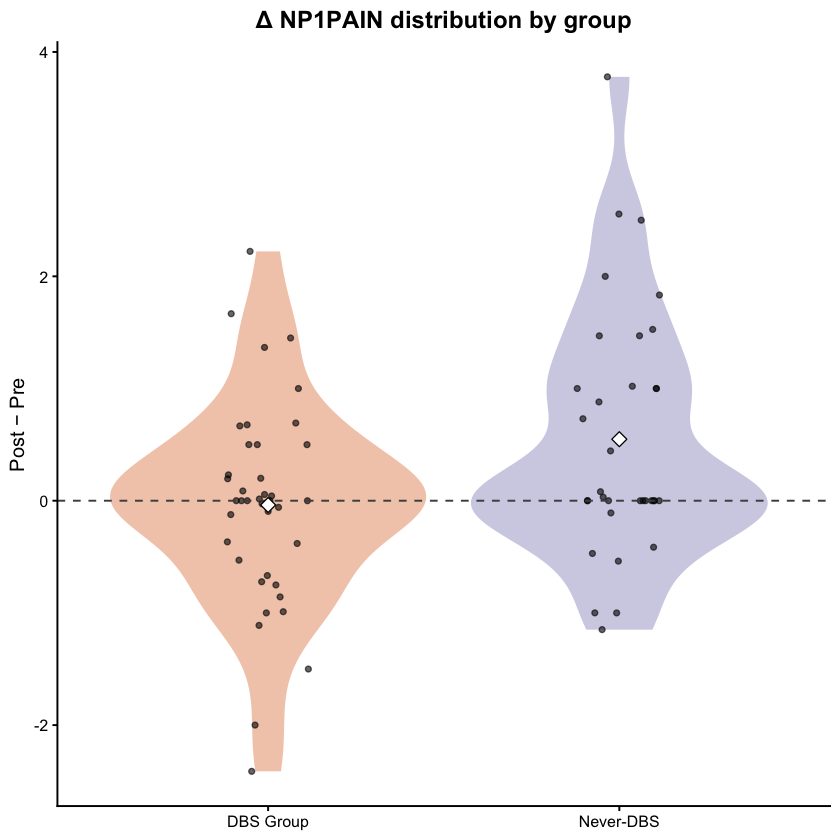

In [9]:
p_violin <- ggplot(delta, aes(x = group, y = delta, fill = group)) +
  geom_violin(alpha = 0.35, colour = NA) +
  geom_jitter(width = 0.12, alpha = 0.6, size = 1.3) +
  geom_hline(yintercept = 0, linetype = "dashed", colour = "grey30") +
  stat_summary(fun = mean, geom = "point", shape = 23, fill = "white", size = 3) +
  scale_fill_manual(values = ARM_COLORS, guide = "none") +
  labs(title = "Δ NP1PAIN distribution by group", x = NULL, y = "Post − Pre") +
  theme_classic(base_size = 12) +
  theme(plot.title = element_text(face = "bold", hjust = 0.5))
p_violin
save_fig(p_violin, "Fig08_delta_violin", width = 5.5, height = 4.3)

In [10]:
# Export responder labels for downstream prediction model
save_object(delta, "pain_delta_responder")
cat("Saved: pain_delta_responder.rds\n")
cat("Columns:", paste(names(delta), collapse = ", "), "\n")

Saved: pain_delta_responder.rds


Columns: PATNO, will_receive_dbs, pre_val, n_pre, post_val, n_post, delta, group, responder 
